## NLP Assignment 3 — Grammar Correction and Legal Case Similarity Retrieval

This assignment is a continuation of Assignment 2, where you developed a Neural Language Model and
generated both extractive and abstractive summaries of legal judgments.

In Assignment 3, we will extend that work in two directions:
1. Refine the abstractive summaries from Assignment 2 by applying grammar correction and
linguistic improvement techniques.

2. Develop a Legal Case Similarity Retrieval System that identifies the most semantically similar
cases based on learned embeddings.

The focus of this task is on language refinement, semantic understanding, and information retrieval
within legal texts.

---

### PART 1 – Grammar Correction & Summary Refinement

Objective
Improve the grammatical accuracy and readability of the abstractive summaries created in Assignment 2.
Your refined summaries should be grammatically correct, coherent, and concise, without altering the
meaning of the original sentences.

In [ ]:
%pip install jsonlines
%pip install language-tool-python

In [13]:
import json
import jsonlines
from tqdm import tqdm
import spacy
import os
import pandas as pd
import re

# Load spaCy NLP model
nlp = spacy.load("en_core_web_sm")

# File paths
input_path = "input_data/final_summaries.jsonl"
output_path = "output_data/corrected_summaries.jsonl"
comparison_csv = "output_data/summary_comparison.csv"

os.makedirs("output_data", exist_ok=True)

print("=" * 80)
print("PART 1: GRAMMAR CORRECTION & SUMMARY REFINEMENT (with Extractive fallback)")
print("=" * 80)


# ===== STEP 1: SENTENCE STRUCTURE FIX =====
def fix_sentence_structures(text):
    text = re.sub(r'\b(\w+)\s+(dismissed?|filed|allowed?|given|executed?|awarded)\b', 
                  lambda m: f"{m.group(1)} was {m.group(2)}d" if not m.group(2).endswith('ed') else m.group(0), 
                  text, flags=re.IGNORECASE)
    
    patterns = [
        (r'\bcourt\s+dismiss\b', 'court was dismissed'),
        (r'\bcourt\s+allow\b', 'court was allowed'),
        (r'\bappeal\s+file\b', 'appeal was filed'),
        (r'\bappeal\s+dismiss\b', 'appeal was dismissed'),
        (r'\bcase\s+dismiss\b', 'case was dismissed'),
        (r'\bcase\s+file\b', 'case was filed'),
        (r'\bjudgment\s+pass\b', 'judgment was passed'),
        (r'\bdecree\s+grant\b', 'decree was granted'),
        (r'\bpetition\s+allow\b', 'petition was allowed'),
        (r'\bcompensation\s+award\b', 'compensation was awarded'),
    ]
    
    for pattern, replacement in patterns:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    text = re.sub(r'\bis\s+been\b', 'has been', text, flags=re.IGNORECASE)
    text = re.sub(r'\bare\s+been\b', 'have been', text, flags=re.IGNORECASE)
    text = re.sub(r'\bwas\s+been\b', 'had been', text, flags=re.IGNORECASE)
    text = re.sub(r'\bwere\s+been\b', 'had been', text, flags=re.IGNORECASE)
    
    text = re.sub(r'\b(defendant|appellant|respondent|plaintiff)\s+(guilty|liable|responsible|liable)\b',
                  r'\1 was \2', text, flags=re.IGNORECASE)
    
    text = re.sub(r'^([A-Z][a-z]+\s+(?:court|judge|appeal|case|judgment))', r'The \1', text)
    text = re.sub(r'([.!?]\s+)([a-z]*[A-Z][a-z]+\s+(?:court|judge|appeal|case|judgment))', r'\1The \2', text)
    
    return text


# ===== STEP 2: FIX SUBJECT-VERB AGREEMENT =====
def fix_agreement(text):
    doc = nlp(text)
    corrected = []
    
    for i, token in enumerate(doc):
        if token.pos_ == "VERB":
            if i > 0:
                prev_tokens = [t.text.lower() for t in doc[max(0, i-3):i]]
                singular_subjects = ['court', 'judge', 'appellant', 'respondent', 'defendant', 'case', 'appeal', 'judgment']
                has_singular = any(s in prev_tokens for s in singular_subjects)
                
                if has_singular:
                    if token.lemma_ == "be":
                        corrected.append("was" if any(t in prev_tokens for t in ['was', 'were']) else "is")
                    elif token.tag_ == "VBP":
                        corrected.append(token.lemma_)
                    else:
                        corrected.append(token.text)
                else:
                    corrected.append(token.text)
            else:
                corrected.append(token.text)
        else:
            corrected.append(token.text)
    
    return " ".join(corrected)


# ===== STEP 3: BASIC CLEANUP & FORMATTING =====
def cleanup_text(text):
    text = text.strip()
    if text:
        text = text[0].upper() + text[1:]
    
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    text = re.sub(r'([.,!?;:])\s*([A-Z])', r'\1 \2', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\b(\w+)(\s+\1)+\b', r'\1', text, flags=re.IGNORECASE)
    
    return text


# ===== STEP 4: IMPROVE SENTENCE FLOW =====
def improve_flow(text):
    legal_terms = {
        'court': 'Court', 'judge': 'Judge', 'appeal': 'Appeal',
        'judgment': 'Judgment', 'decree': 'Decree', 'case': 'Case',
        'appellant': 'Appellant', 'respondent': 'Respondent',
        'defendant': 'Defendant', 'plaintiff': 'Plaintiff'
    }
    
    for word, proper in legal_terms.items():
        text = re.sub(rf'\b{word}\b', proper, text, flags=re.IGNORECASE)
    
    text = re.sub(r'([.!?])\s+([A-Z][a-z]+\s+was\s)', r'\1 Therefore, \2', text)
    
    return text


# ===== MAIN CORRECTION PIPELINE =====
def correct_summary(record):
    abstractive = record.get("abstractive_summary", "")
    extractive = record.get("extractive_summary", "")
    
    # Prefer abstractive if not empty, else fallback to extractive
    combined = abstractive if abstractive.strip() else extractive
    if not combined.strip():
        return ""
    
    # Apply fixes in sequence
    text = fix_sentence_structures(combined)
    text = fix_agreement(text)
    text = improve_flow(text)
    text = cleanup_text(text)
    
    return text


# ===== LOAD AND PROCESS SUMMARIES =====
results = []

with jsonlines.open(input_path) as reader:
    summaries = list(reader)

print(f">> Loaded {len(summaries)} summaries")
print("> Correcting and refining...")

with jsonlines.open(output_path, mode='w') as writer:
    for record in tqdm(summaries, desc="Processing"):
        case_id = record.get("case_id", "N/A")
        original_abs = record.get("abstractive_summary", "")
        original_ext = record.get("extractive_summary", "")
        
        corrected = correct_summary(record)
        
        writer.write({
            "case_id": case_id,
            "original_abstractive": original_abs,
            "original_extractive": original_ext,
            "corrected_summary": corrected
        })
        
        results.append({
            "Case No.": case_id,
            "Original Abstractive Summary": original_abs,
            "Original Extractive Summary": original_ext,
            "Corrected Summary": corrected
        })

df = pd.DataFrame(results)
df.to_csv(comparison_csv, index=False)

print("\nSAMPLE RESULTS (First 5 cases)")
for i, result in enumerate(results[:5], 1):
    print(f"\n[Case {i}] {result['Case No.']}")
    print(f"  Original Abstractive: {result['Original Abstractive Summary']}")
    print(f"  Original Extractive:  {result['Original Extractive Summary']}")
    print(f"  Corrected:            {result['Corrected Summary']}")

print("\n>> CORRECTION COMPLETE")
print(f"✓ Corrected summaries: {output_path}")
print(f"✓ Comparison table:   {comparison_csv}")
print(f"✓ Cases processed:    {len(results)}")


PART 1: GRAMMAR CORRECTION & SUMMARY REFINEMENT (with Extractive fallback)
>> Loaded 907 summaries
> Correcting and refining...


Processing: 100%|██████████| 907/907 [00:03<00:00, 256.69it/s]


SAMPLE RESULTS (First 5 cases)

[Case 1] C.A._1022_2012
  Original Abstractive: Supreme court zaheer pakistan amir appellate anwar
  Original Extractive:  IN THE SUPREME COURT OF PAKISTAN (APPELLATE JURISDICTION) PRESENT: MR. JUSTICE ANWAR ZAHEER JAMALI, HCJ MR. JUSTICE AMIR HANI MUSLIM MR. JUSTICE FAISAL ARAB CIVIL APPEAL NO. 2 and another ...Respondents For the Appellant: Mr. Wasim Sajjad, Sr. ASC For the Respondents: Mr. Nasir Mehmood Mughal, Special Prosecutor, NAB For the Federation: Mr. Abdur Rasheed Awan, DAG Date of Hearing: 06.06.2016 ORDER ANWAR ZAHEER JAMALI, CJ.We have heard the arguments of the learned ASC for the appellant and the learned Special Prosecutor General, NAB. CHIEF JUSTICE JUDGE JUDGE Islamabad, the 6th of June, 2016 Not Approved For Reporting
  Corrected:            The Supreme Court zaheer pakistan amir appellate anwar

[Case 2] C.A._1125_2014
  Original Abstractive: Connected date learn short hearing press valid judgment seek
  Original Extractive:  Date o

---

### Part 2 – Legal Case Similarity Retrieval

In [19]:
import jsonlines
import numpy as np
import pandas as pd
from numpy import dot
from numpy.linalg import norm
import os

# ===== PARAMETERS =====
input_file = "input_data/nlm_results_complete.jsonl"
all_output_file = "output_data/similarity_all.csv"
topk_output_file = "output_data/similarity_top10.csv"
TOP_DISPLAY = 3
TOP_SAVE = 10
query_cases = ["C.A._1022_2012", "C.A._1125_2014"]  # replace with your query case IDs

os.makedirs("output_data", exist_ok=True)

# ===== HELPER FUNCTION =====
def cosine_similarity(vec1, vec2):
    return dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# ===== LOAD AND COMPUTE DOCUMENT EMBEDDINGS =====
case_embeddings = {}

with jsonlines.open(input_file) as reader:
    for record in reader:
        case_id = record['case_id']
        sentences = record['sentence_embeddings']
        if sentences:
            doc_embedding = np.mean(np.array(sentences), axis=0)
            case_embeddings[case_id] = doc_embedding

# ===== COMPUTE SIMILARITY =====
all_results = []
topk_results = []

for query_case in query_cases:
    if query_case not in case_embeddings:
        print(f"Warning: Query case {query_case} not found!")
        continue

    query_vec = case_embeddings[query_case]

    similarities = [
        (other_id, cosine_similarity(query_vec, emb))
        for other_id, emb in case_embeddings.items() if other_id != query_case
    ]

    # Save all similarities
    for sim_case, score in similarities:
        all_results.append({
            "Query Case No.": query_case,
            "Similar Case No.": sim_case,
            "Similarity Score": round(score, 4)
        })

    # Save Top-10
    top_k = sorted(similarities, key=lambda x: x[1], reverse=True)[:TOP_SAVE]
    for sim_case, score in top_k:
        topk_results.append({
            "Query Case No.": query_case,
            "Similar Case No.": sim_case,
            "Similarity Score": round(score, 4)
        })

# ===== SAVE TO CSV =====
pd.DataFrame(all_results).to_csv(all_output_file, index=False)
pd.DataFrame(topk_results).to_csv(topk_output_file, index=False)

# ===== DISPLAY TOP 3 =====
print("\n>> Top 3 similar cases per query:")
top3_display = pd.DataFrame(topk_results).groupby("Query Case No.").head(TOP_DISPLAY)
print(top3_display.to_string(index=False))

print(f"\n All similarity scores saved to: {all_output_file}")
print(f">> Top-10 similar cases saved to: {topk_output_file}")



>> Top 3 similar cases per query:
Query Case No.             Similar Case No.  Similarity Score
C.A._1022_2012      judgement_C.A.1022-2012            1.0000
C.A._1022_2012      judgement_C.A.1213-2015            0.9997
C.A._1022_2012 judgement_Crl.P.L.A.198-2016            0.9996
C.A._1125_2014      judgement_C.A.1125-2014            1.0000
C.A._1125_2014  judgement_C.P.L.A.3317-2018            0.9990
C.A._1125_2014                C.A._308_2014            0.9989

 All similarity scores saved to: output_data/similarity_all.csv
>> Top-10 similar cases saved to: output_data/similarity_top10.csv


---

### Visualizations + Bonus
visualising the results for ease of viewing results

In [ ]:
%pip install seaborn
%pip install matplotlib

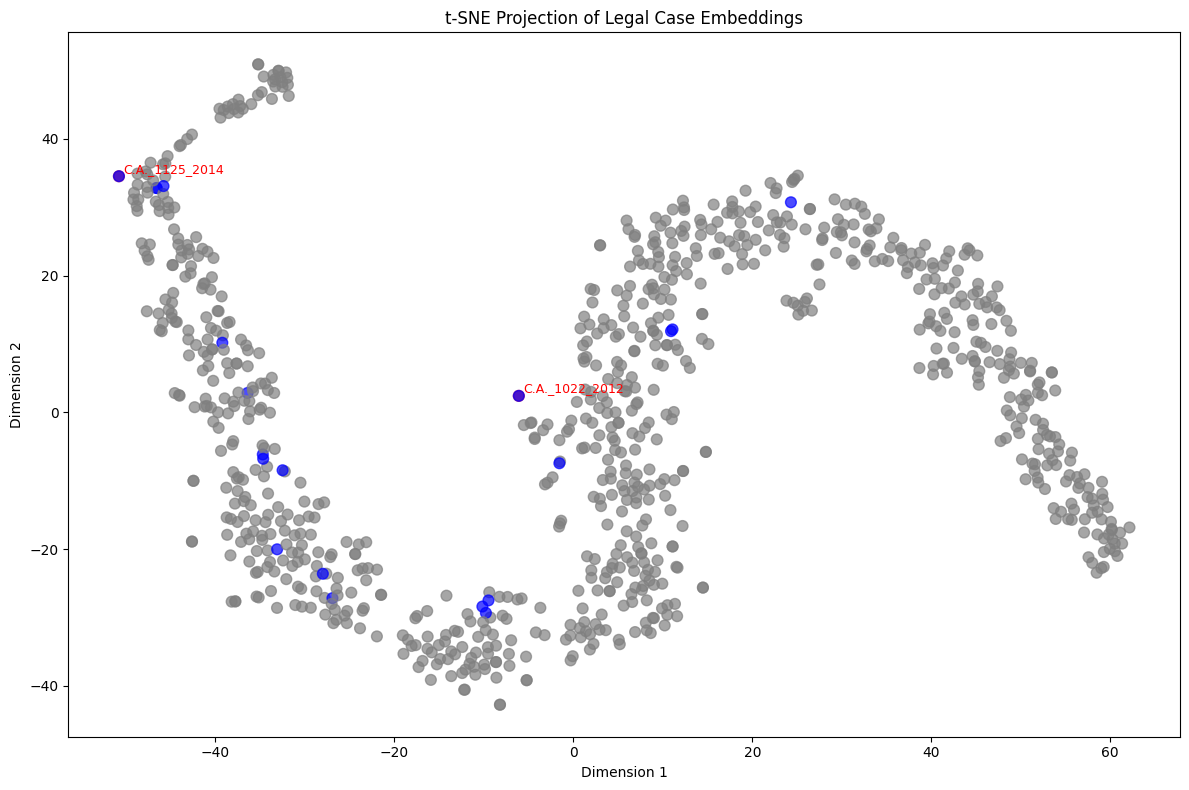

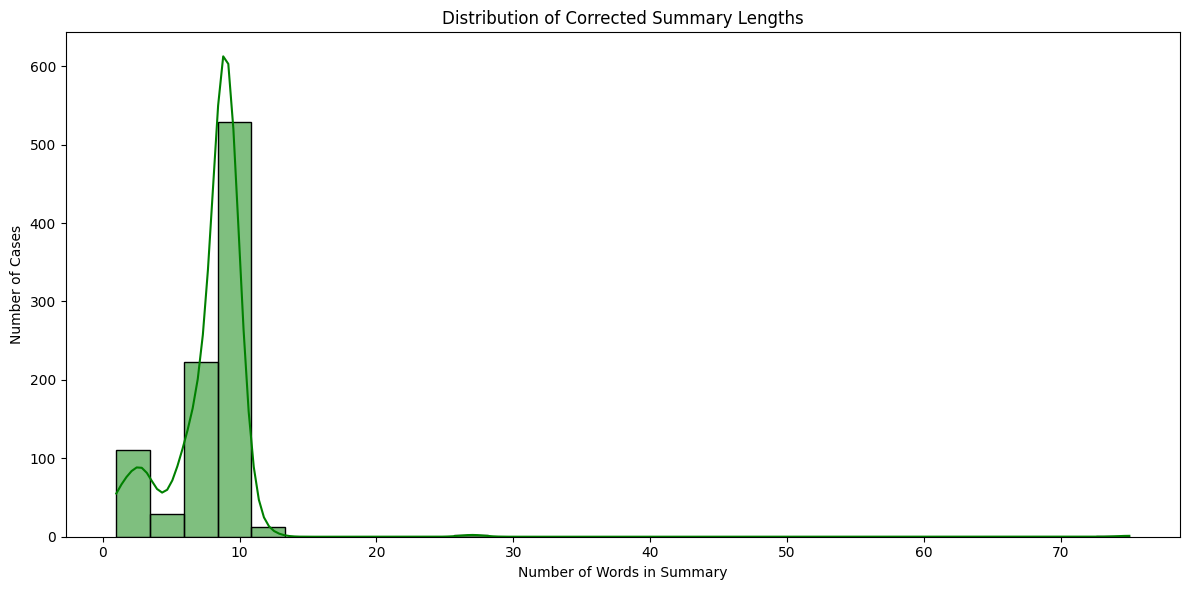

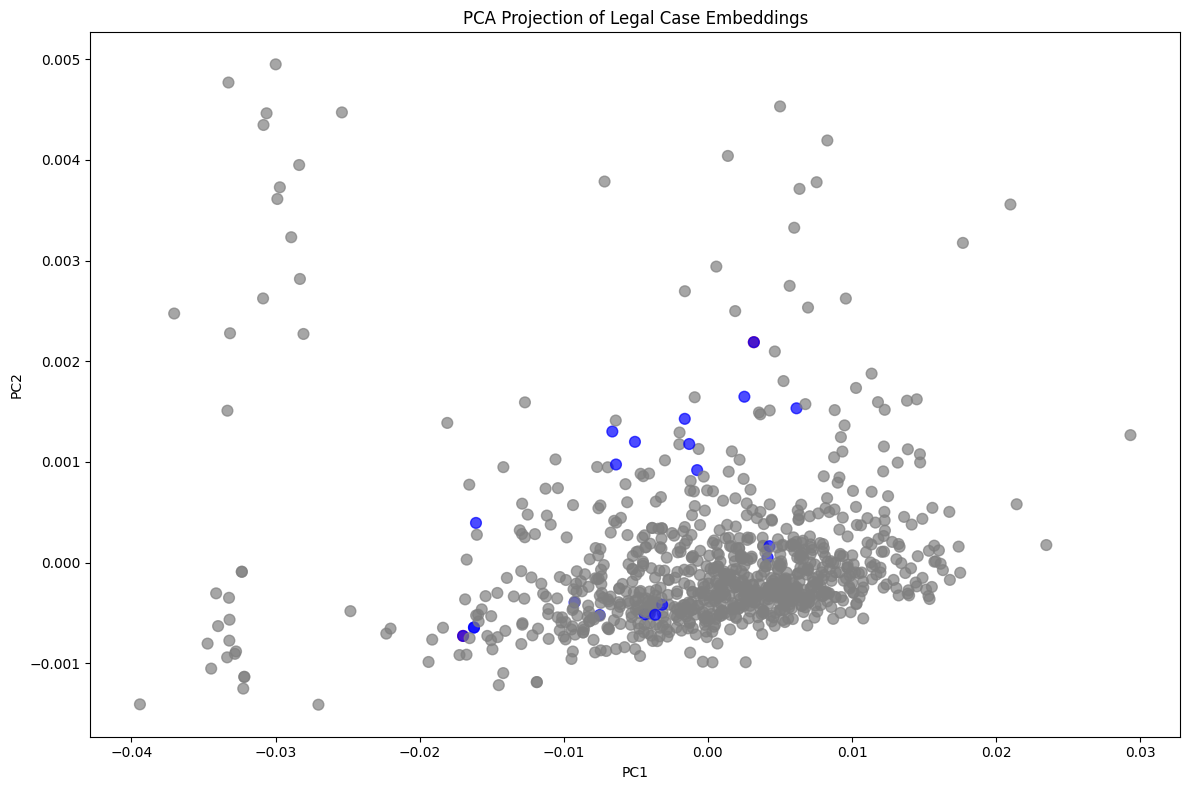

✅ Visualizations saved in output_data/visualizations


In [23]:
import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import os

# ===== FILE PATHS =====
nlm_file = "input_data/nlm_results_complete.jsonl"
topk_file = "output_data/similarity_top10.csv"
summary_file = "output_data/corrected_summaries.jsonl"
output_dir = "output_data/visualizations"
os.makedirs(output_dir, exist_ok=True)

# ===== LOAD CASE EMBEDDINGS =====
case_ids = []
embeddings = []

with jsonlines.open(nlm_file) as reader:
    for record in reader:
        case_ids.append(record['case_id'])
        emb = np.mean(np.array(record['sentence_embeddings']), axis=0)
        embeddings.append(emb)

embeddings = np.array(embeddings)

# ===== PART 2: t-SNE / PCA VISUALIZATION OF EMBEDDINGS =====
# Using t-SNE for 2D projection
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
emb_2d = tsne.fit_transform(embeddings)

# Load Top-K similar cases
topk_df = pd.read_csv(topk_file)
topk_cases = set(topk_df['Similar Case No.'].tolist())
query_cases = set(topk_df['Query Case No.'].tolist())

# Create a color map
colors = []
for cid in case_ids:
    if cid in query_cases:
        colors.append('red')       # Query cases
    elif cid in topk_cases:
        colors.append('blue')      # Top-K similar
    else:
        colors.append('gray')      # Other cases

plt.figure(figsize=(12,8))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=colors, alpha=0.7, s=60)
plt.title("t-SNE Projection of Legal Case Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# Annotate query cases
for i, cid in enumerate(case_ids):
    if cid in query_cases:
        plt.text(emb_2d[i,0]+0.5, emb_2d[i,1]+0.5, cid, fontsize=9, color='red')

plt.tight_layout()
plt.savefig(f"{output_dir}/case_embeddings_tsne.png")
plt.show()

# ===== PART 1: SUMMARY LENGTHS VISUALIZATION =====
summary_lengths = []
summary_ids = []

with jsonlines.open(summary_file) as reader:
    for record in reader:
        summary_ids.append(record['case_id'])
        text = record.get('corrected_summary', '')
        summary_lengths.append(len(text.split()))

plt.figure(figsize=(12,6))
sns.histplot(summary_lengths, bins=30, kde=True, color='green')
plt.title("Distribution of Corrected Summary Lengths")
plt.xlabel("Number of Words in Summary")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.savefig(f"{output_dir}/summary_lengths.png")
plt.show()

# ===== OPTIONAL: PCA 2D of embeddings =====
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(12,8))
plt.scatter(emb_pca[:,0], emb_pca[:,1], c=colors, alpha=0.7, s=60)
plt.title("PCA Projection of Legal Case Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(f"{output_dir}/case_embeddings_pca.png")
plt.show()

print(f"✅ Visualizations saved in {output_dir}")


---